<a href="https://colab.research.google.com/github/MBAH05/QC_MIMI_Project/blob/main/MINI_PROJECT_3_MULTI_CONTROLLED_U_GATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT #1

# MINI-PROJECT #3: MULTI-CONTROLLED U GATE

# Problem to solve
Write a Qiskit function that takes two inputs: a positive integer $n$ and a matrix $U \in U(2)$ and outputs a quantum circuit on $n+1$ qubits, possibly with further ancillas, that implements a multi controlled $U$ gate, $C^nU$, that is:
$$C^nU|x\rangle_n|y\rangle_1=\begin{cases}\;|x\rangle_nU|y\rangle_1\,, & \text{if } x=(1, 1, \ldots, 1)\\ \;|x\rangle_n|y\rangle_1\,, & \text{otherwise}\end{cases}$$


# Install qiskit and numpy

In [10]:
!pip install qiskit

# For circuit drawing install

In [11]:
!pip install pylatexenc
import pylatexenc

# Imports

In [12]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import random_unitary
from qiskit.visualization import plot_histogram
from IPython.display import display

# Function Definition: cn_u_linear_ancilla:

This function creates a controlled-NOT unitary gate with ancillas to apply a unitary U based on the number of qubits.

In [13]:
def cn_u_linear_ancilla(n, U):
    if n < 1: raise ValueError("n must be >= 1")  # Basic validation

    U = np.asanyarray(U, dtype=complex)
    if U.shape != (2, 2):
        raise ValueError("We need U to be a 2x2 matrix!")

    # Create registers
    controls = QuantumRegister(n, "c")
    target = QuantumRegister(1, "t")

    myQuantumCircuit = QuantumCircuit(controls, target, name=f"C^{n}U")

    U_gate = UnitaryGate(U, label="U")

    if n == 1:  # Special case for single control
        myQuantumCircuit.append(U_gate.control(1), [controls[0], target[0]])
        return myQuantumCircuit

    ancillas = QuantumRegister(n-1, "a")  # Ancilla register for multi-control gates
    myQuantumCircuit.add_register(ancillas)

    # Handle larger n
    for i in range(n - 1):  # Correct logic for CNOT chain
        if i == 0:
            myQuantumCircuit.ccx(controls[i], controls[i+1], ancillas[i])  # First control
        elif i == n - 2:
            myQuantumCircuit.append(U_gate.control(1), [ancillas[i], target[0]])  # Apply U on the last ancilla
        else:
            myQuantumCircuit.ccx(ancillas[i-1], controls[i+1], ancillas[i])  # CCX chaining

    # Reverse sequence of operations
    for i in reversed(range(n - 2)):
        myQuantumCircuit.ccx(ancillas[i], controls[i+1], ancillas[i+1])

    return myQuantumCircuit


## Testing the Circuit:

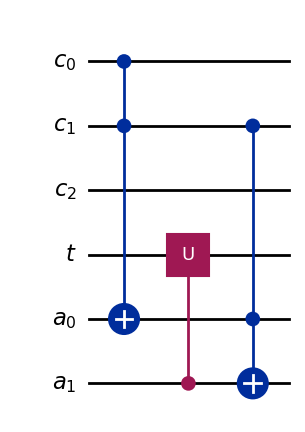

In [14]:
# Test with random unitary and n=3
n = 3
U = random_unitary(2).data
thisQuantumCircuit = cn_u_linear_ancilla(n, U)

# Display the circuit in Colab
display(thisQuantumCircuit.draw("mpl"))

### Author Maraf